In [1]:
import pandas as pd #used for data manipulation.
import numpy as np #used for mathematical functions.
import matplotlib.pyplot as plt #used for charts.
import matplotlib
%matplotlib inline
import seaborn as sns #used for complex charts.

matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.dpi'] = 150

from IPython.core.pylabtools import figsize

In [2]:
EDA = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')

In [3]:
EDA.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


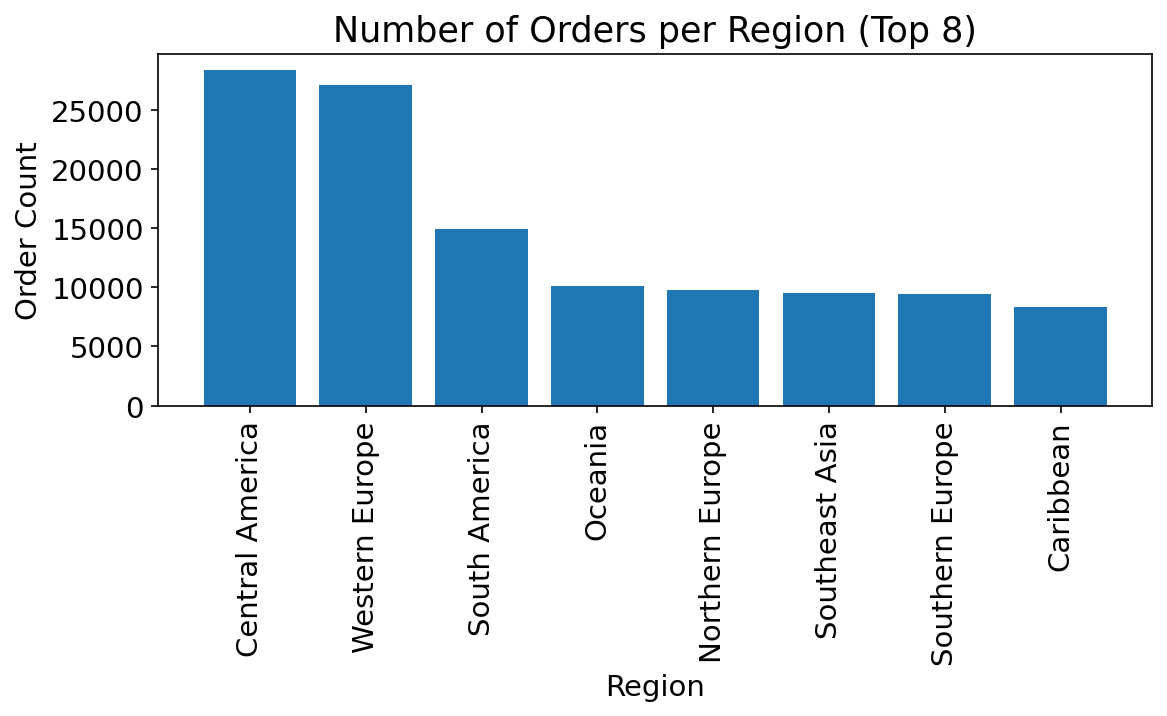

In [4]:
# Select top 8 regions
orders_region_top = EDA["Order Region"].value_counts().head(8)

plt.figure(figsize=(8, 5))
plt.bar(orders_region_top.index, orders_region_top.values)
plt.title("Number of Orders per Region (Top 8)")
plt.ylabel("Order Count")
plt.xlabel("Region")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

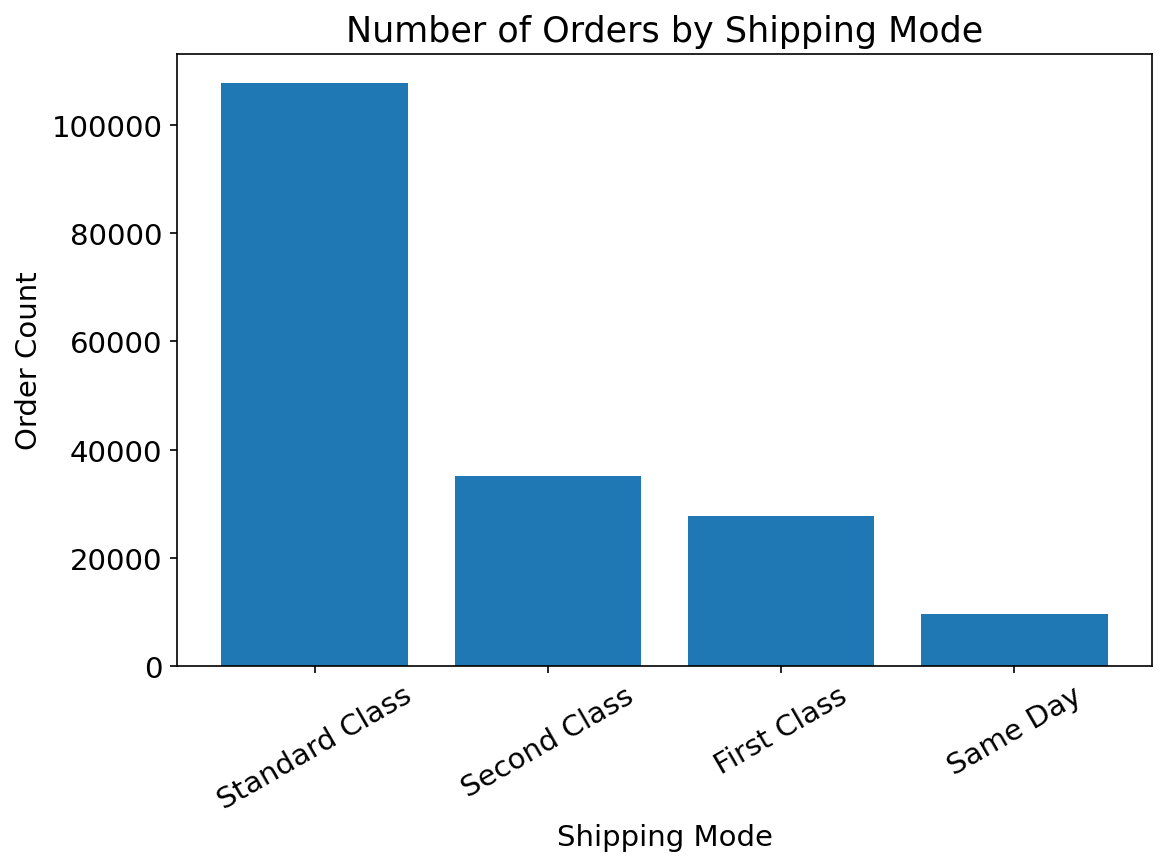

In [5]:
# Count orders by shipping mode
orders_shipping = EDA["Shipping Mode"].value_counts()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(orders_shipping.index, orders_shipping.values)
plt.title("Number of Orders by Shipping Mode")
plt.ylabel("Order Count")
plt.xlabel("Shipping Mode")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

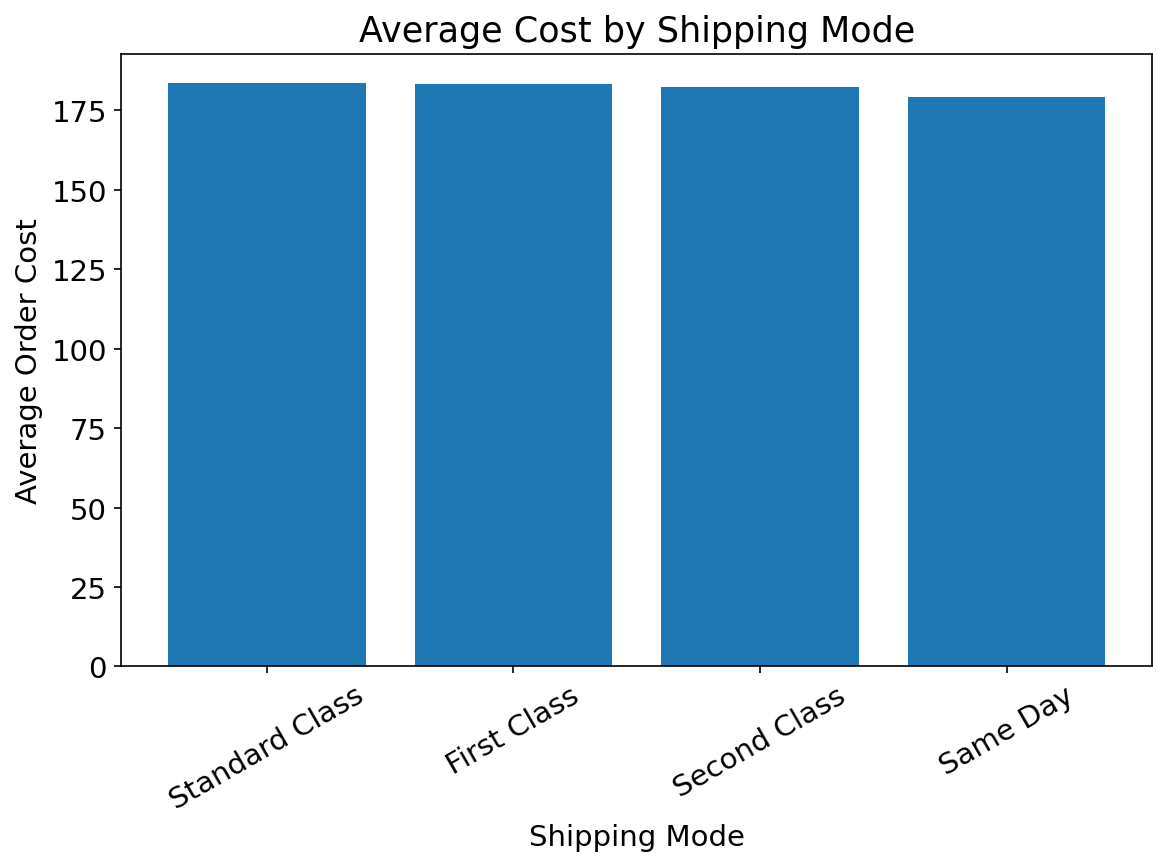

In [6]:
# Compute average cost per shipping mode
avg_cost_shipping = (
    EDA.groupby("Shipping Mode")["Order Item Total"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8, 6))
plt.bar(avg_cost_shipping.index, avg_cost_shipping.values)
plt.title("Average Cost by Shipping Mode")
plt.ylabel("Average Order Cost")
plt.xlabel("Shipping Mode")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [7]:
df = EDA[["Type","Days for shipping (real)","Days for shipment (scheduled)","Late_delivery_risk","Order Country","Order Item Discount","Order Item Quantity","Order Item Total","Order Profit Per Order","Order Region","Product Category Id","Product Price","Shipping Mode"
          ]]

In [8]:
# Recalculate Late_delivery_risk
df["Late_delivery_risk"] = (
df["Days for shipping (real)"] -
df["Days for shipment (scheduled)"]
)

C:\Users\jason\AppData\Local\Temp\ipykernel_17472\1337249024.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Late_delivery_risk"] = (


In [9]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Late_delivery_risk,Order Country,Order Item Discount,Order Item Quantity,Order Item Total,Order Profit Per Order,Order Region,Product Category Id,Product Price,Shipping Mode
0,DEBIT,3,4,-1,Indonesia,13.110000,1,314.640015,91.250000,Southeast Asia,73,327.75,Standard Class
1,TRANSFER,5,4,1,India,16.389999,1,311.359985,-249.089996,South Asia,73,327.75,Standard Class
2,CASH,4,4,0,India,18.030001,1,309.720001,-247.779999,South Asia,73,327.75,Standard Class
3,DEBIT,3,4,-1,Australia,22.940001,1,304.809998,22.860001,Oceania,73,327.75,Standard Class
4,PAYMENT,2,4,-2,Australia,29.500000,1,298.250000,134.210007,Oceania,73,327.75,Standard Class


In [10]:
df.count()

Type                             180519
Days for shipping (real)         180519
Days for shipment (scheduled)    180519
Late_delivery_risk               180519
Order Country                    180519
Order Item Discount              180519
Order Item Quantity              180519
Order Item Total                 180519
Order Profit Per Order           180519
Order Region                     180519
Product Category Id              180519
Product Price                    180519
Shipping Mode                    180519
dtype: int64

In [11]:
df['Order Profit Per Order'].describe()

count    180519.000000
mean         21.974989
std         104.433526
min       -4274.979980
25%           7.000000
50%          31.520000
75%          64.800003
max         911.799988
Name: Order Profit Per Order, dtype: float64

In [12]:
# Count missing values per column
missing_counts = df.isna().sum()


# Show only columns with missing data
missing_counts[missing_counts > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [13]:
# Profit per region
profit_region = (
    df.groupby("Order Region")["Order Profit Per Order"]
    .mean()
    .sort_values(ascending=False)
    .head(10)  # top 10 regions
)

# Profit per shipping type
profit_shipping = (
    df.groupby("Shipping Mode")["Order Profit Per Order"]
    .mean()
)

# Late delivery risk by region
late_region = (
    df.groupby("Order Region")["Late_delivery_risk"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Late delivery risk by shipping type
late_shipping = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
    .mean()
)

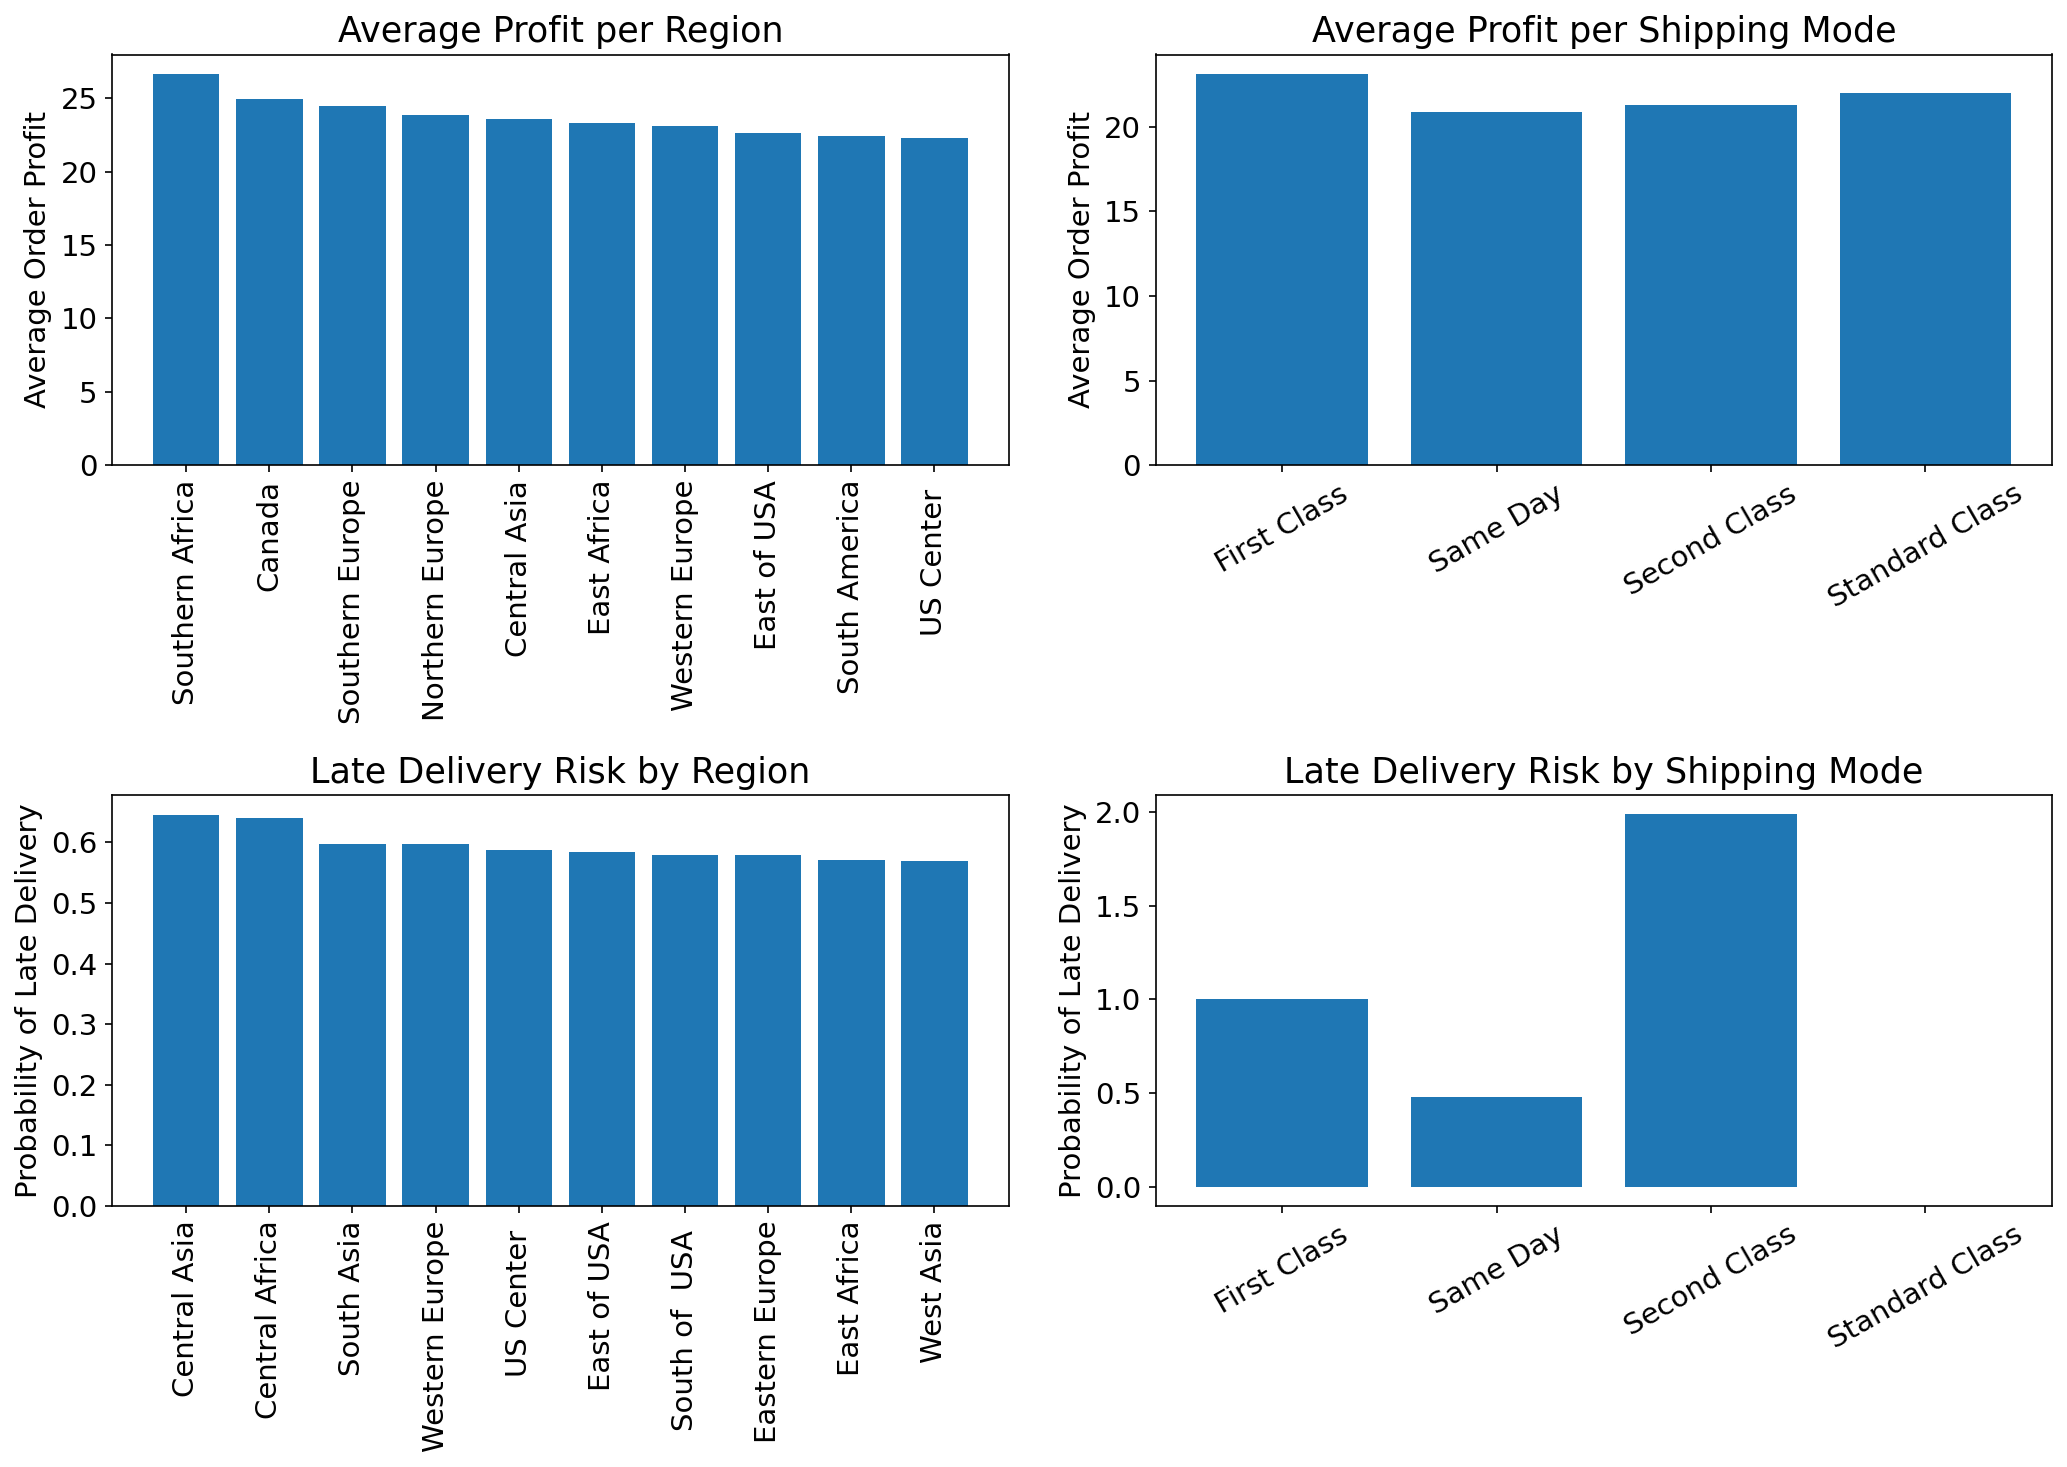

In [14]:
import matplotlib.pyplot as plt 
# ----------------------------- 
# Helper function for bar plots 
# ----------------------------- 
def bar_plot(ax, x, y, title, ylabel, rotation=0):
    ax.bar(x, y)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=rotation)

# ----------------------------- 
# Create subplots 
# ----------------------------- 
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) 
plots = [ (axes[0, 0], profit_region.index, profit_region.values, "Average Profit per Region", "Average Order Profit", 90), 
         (axes[0, 1], profit_shipping.index, profit_shipping.values, "Average Profit per Shipping Mode", "Average Order Profit", 30), 
         (axes[1, 0], late_region.index, late_region.values, "Late Delivery Risk by Region", "Probability of Late Delivery", 90), 
         (axes[1, 1], late_shipping.index, late_shipping.values, "Late Delivery Risk by Shipping Mode", "Probability of Late Delivery", 
          30), ] 
for ax, x, y, title, ylabel, rot in plots: 
    bar_plot(ax, x, y, title, ylabel, rot) 
    
plt.tight_layout() 
plt.show()

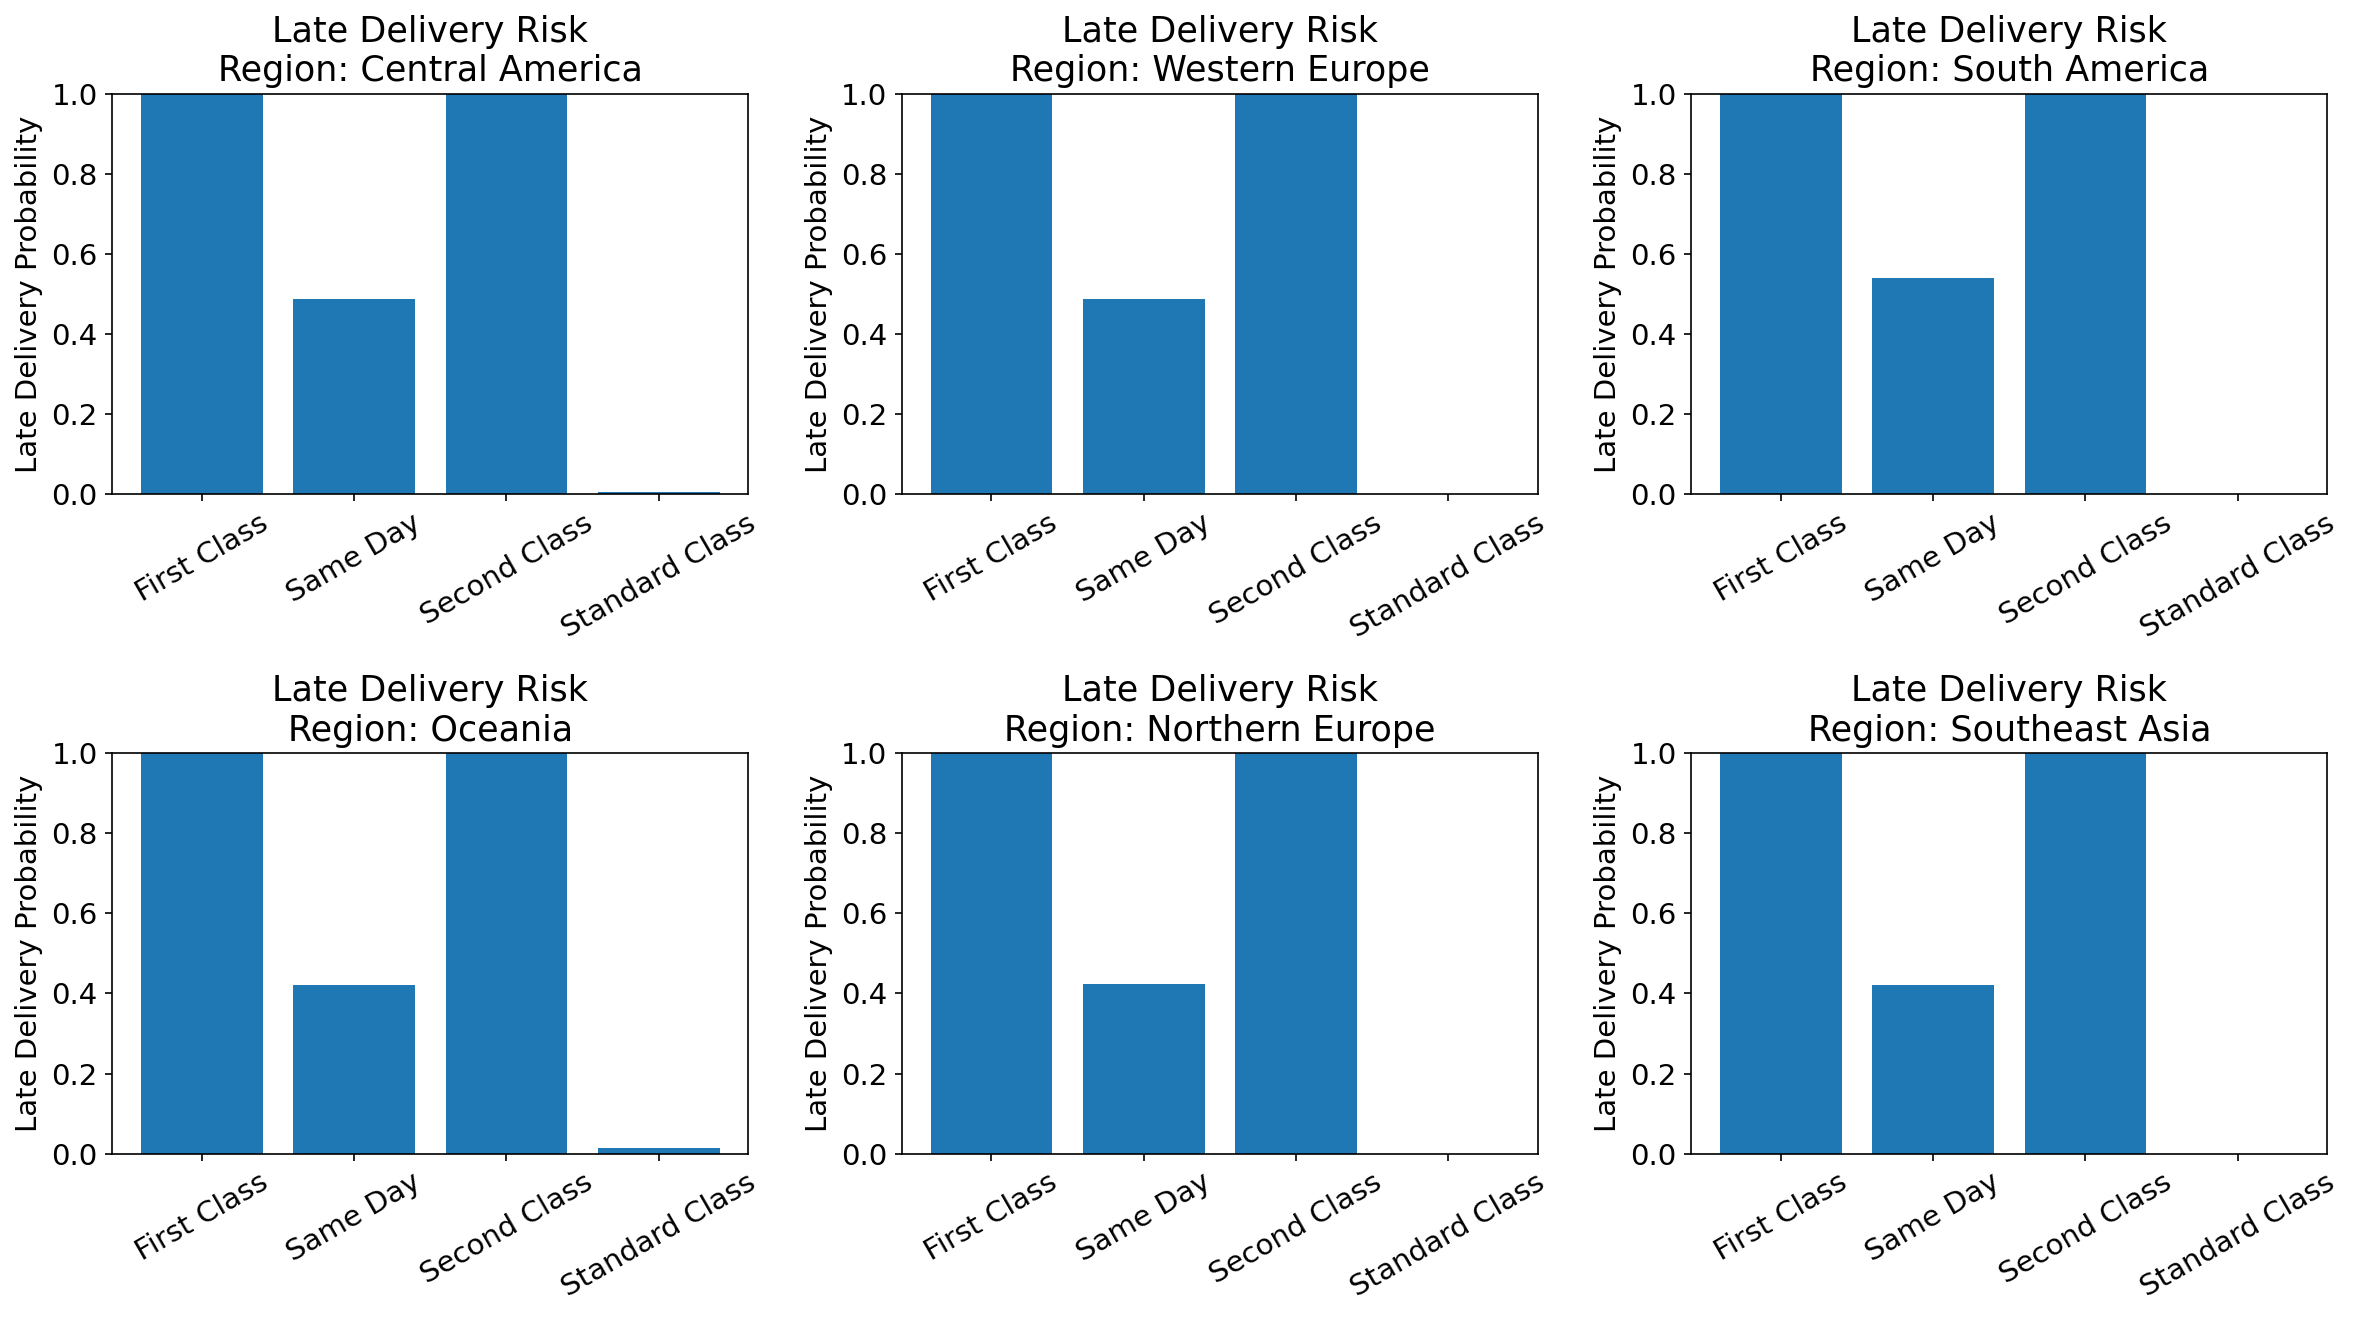

In [15]:
# Select top regions by order volume (readability)
top_regions = df["Order Region"].value_counts().head(6).index

# Aggregate late delivery risk
risk_state_action = (
    df.groupby(["Order Region", "Shipping Mode"])["Late_delivery_risk"]
    .mean()
    .reset_index()
)

risk_state_action = risk_state_action[
    risk_state_action["Order Region"].isin(top_regions)
]

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, region in enumerate(top_regions):
    subset = risk_state_action[
        risk_state_action["Order Region"] == region
    ]

    axes[i].bar(
        subset["Shipping Mode"],
        subset["Late_delivery_risk"]
    )
    axes[i].set_title(f"Late Delivery Risk\nRegion: {region}")
    axes[i].set_ylabel("Late Delivery Probability")
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [16]:
df["Order Region"] = (
df["Order Region"]
.astype(str)
.str.strip()
.str.title()
)

C:\Users\jason\AppData\Local\Temp\ipykernel_17472\3761040597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order Region"] = (


In [17]:
print(df["Order Region"].value_counts().head(10))

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West Of Usa         7993
South Asia          7731
Name: count, dtype: int64


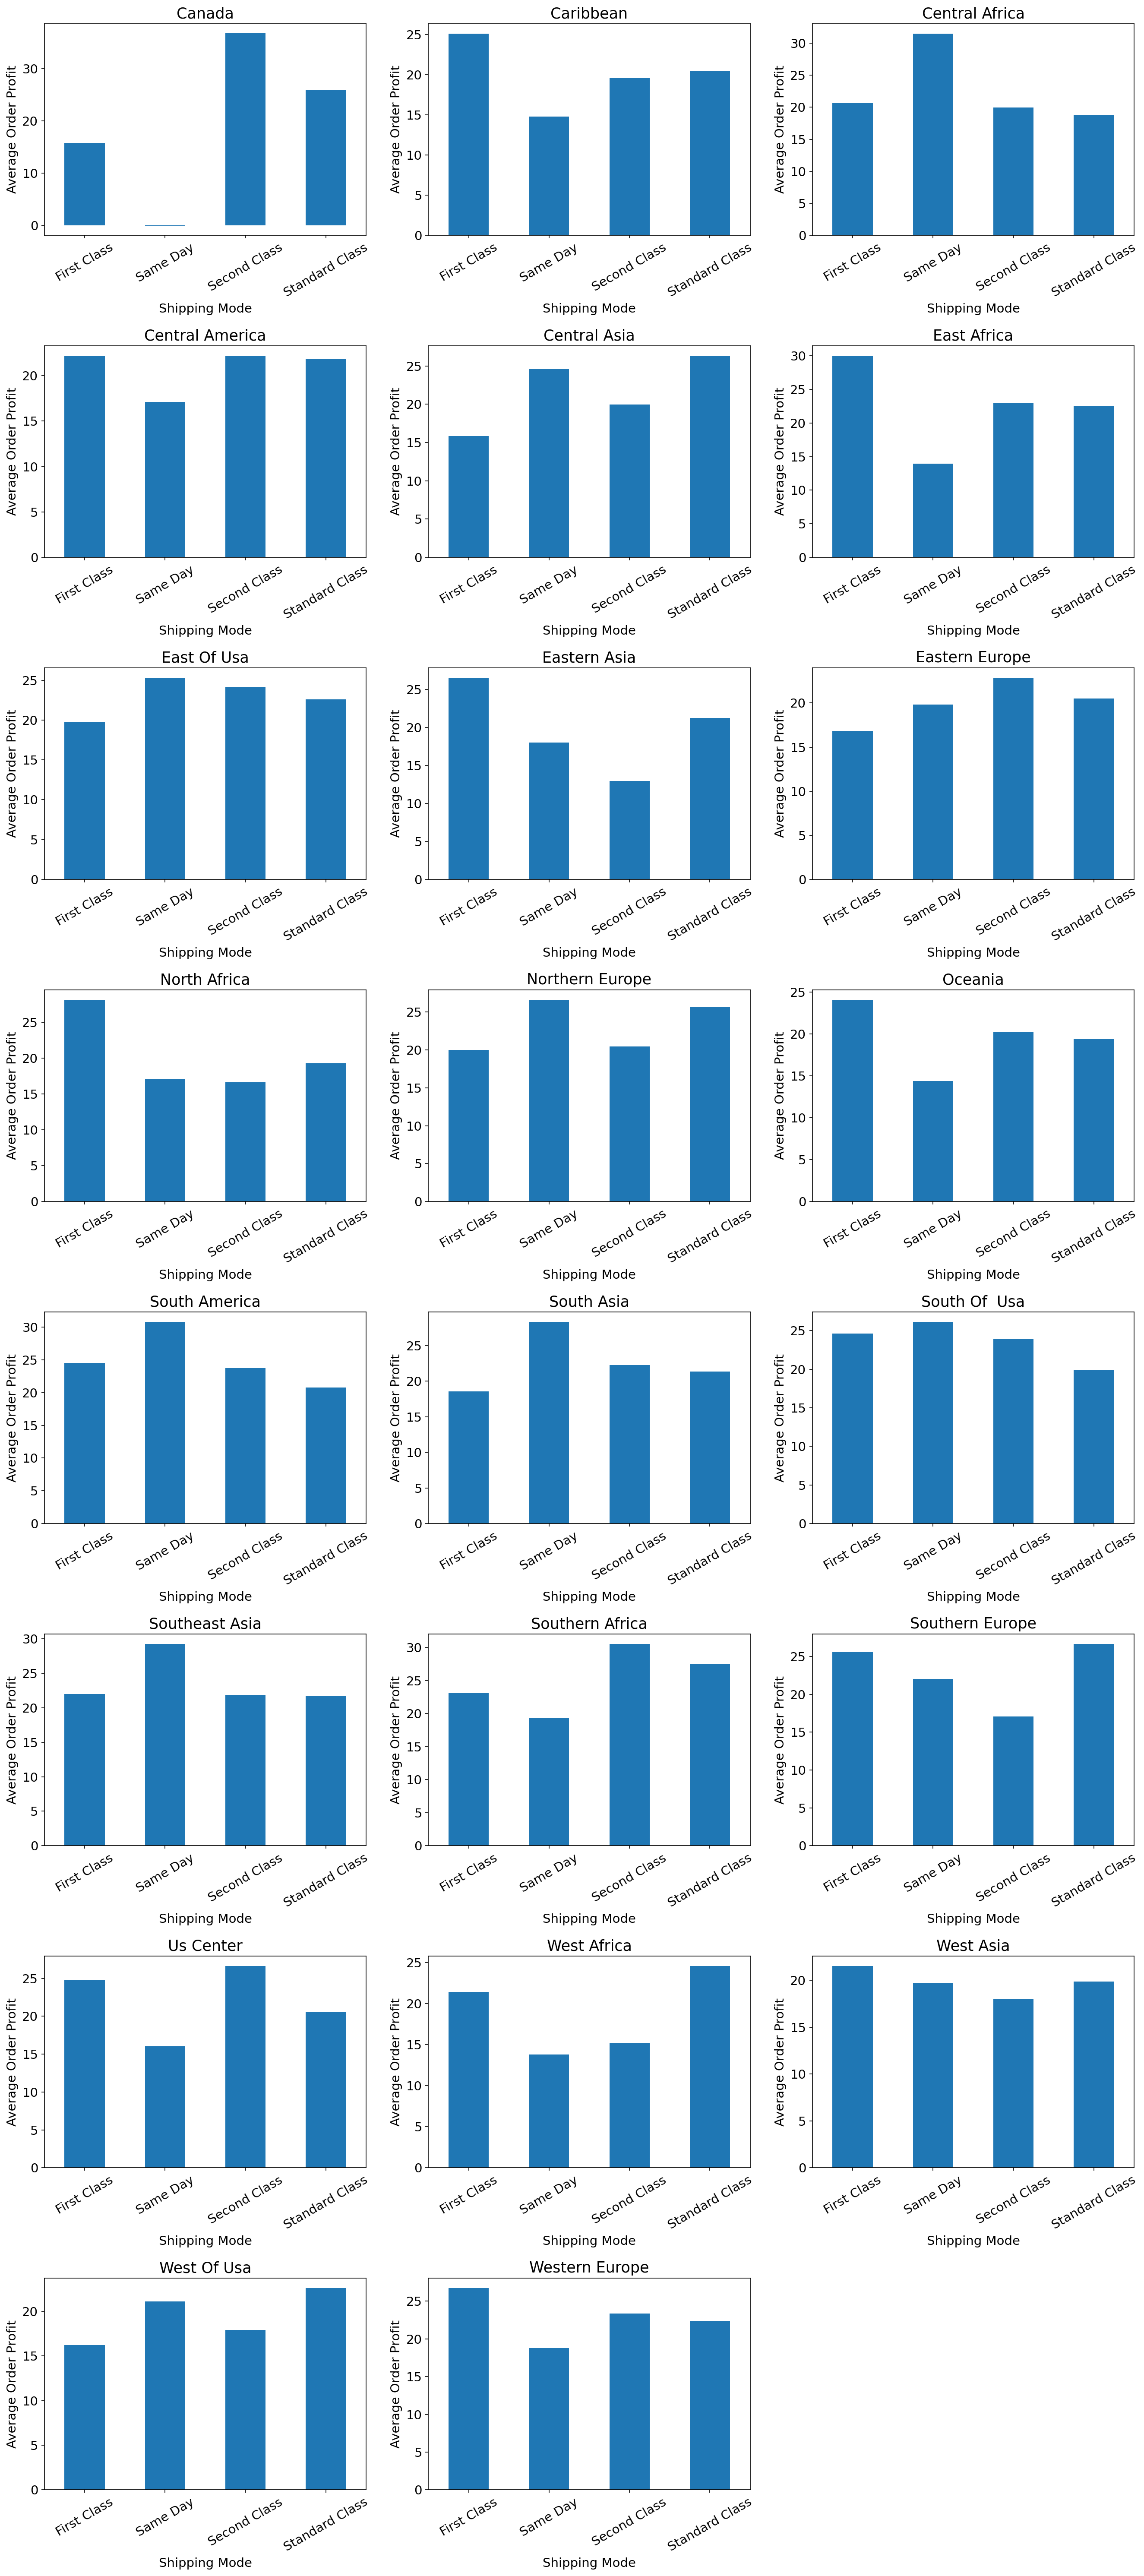

In [18]:
import matplotlib.pyplot as plt
import numpy as np


# Pivot table (rock solid)
pivot = df.pivot_table(
values="Order Profit Per Order",
index="Order Region",
columns="Shipping Mode",
aggfunc="mean"
)


regions = pivot.index.tolist()
n_regions = len(regions)


ncols = 3
nrows = int(np.ceil(n_regions / ncols))


fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = np.atleast_1d(axes).flatten()


for i, region in enumerate(regions):
    pivot.loc[region].plot(kind="bar", ax=axes[i])
    axes[i].set_title(region)
    axes[i].set_ylabel("Average Order Profit")
    axes[i].tick_params(axis="x", rotation=30)


# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

In [19]:
# Check for profit outliers
Q1 = df["Order Profit Per Order"].quantile(0.25)
Q3 = df["Order Profit Per Order"].quantile(0.75)
IQR = Q3 - Q1


lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


outliers_global = df[
(df["Order Profit Per Order"] < lower) |
(df["Order Profit Per Order"] > upper)
]


print("Global outliers:", len(outliers_global))
outliers_global[["Order Region", "Shipping Mode", "Order Profit Per Order"]].head()

Global outliers: 18942


,Order Region,Shipping Mode,Order Profit Per Order
1,South Asia,Standard Class,-249.089996
2,South Asia,Standard Class,-247.779999
15,South Asia,First Class,-259.579987
16,Eastern Asia,Second Class,-246.360001
20,South Asia,Same Day,154.860001


In [20]:
def iqr_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    return group[
    (group < Q1 - 1.5 * IQR) |
    (group > Q3 + 1.5 * IQR)
    ]


outliers_region = (
df.groupby("Order Region")["Order Profit Per Order"]
.apply(iqr_outliers)
)


print("Outliers by region:")
print(outliers_region.groupby(level=0).count())

Outliers by region:
Order Region
Canada              105
Caribbean           872
Central Africa      179
Central America    3018
Central Asia         57
East Africa         192
East Of Usa         740
Eastern Asia        798
Eastern Europe      414
North Africa        330
Northern Europe    1064
Oceania            1054
South America      1566
South Asia          763
South Of  Usa       413
Southeast Asia      978
Southern Africa     113
Southern Europe     963
Us Center           581
West Africa         374
West Asia           673
West Of Usa         846
Western Europe     2834
Name: Order Profit Per Order, dtype: int64


In [21]:
outliers_region_shipping = (
df.groupby(["Order Region", "Shipping Mode"])["Order Profit Per Order"]
.apply(iqr_outliers)
)


print("Outliers by region & shipping mode:")
print(outliers_region_shipping.groupby(level=[0, 1]).count())

Outliers by region & shipping mode:
Order Region    Shipping Mode 
Canada          First Class         24
                Same Day             4
                Second Class        19
                Standard Class      57
Caribbean       First Class        107
                                  ... 
West Of Usa     Standard Class     478
Western Europe  First Class        419
                Same Day           165
                Second Class       553
                Standard Class    1690
Name: Order Profit Per Order, Length: 92, dtype: int64


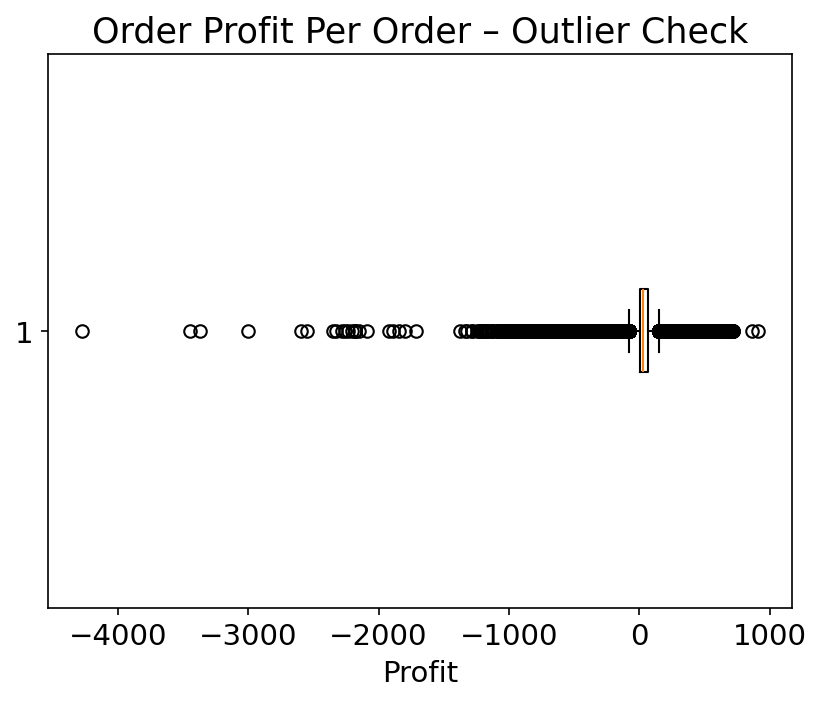

In [22]:
plt.boxplot(df["Order Profit Per Order"], vert=False)
plt.title("Order Profit Per Order – Outlier Check")
plt.xlabel("Profit")
plt.show()

In [23]:
df["Order Profit Per Order_log"] = np.log1p(df["Order Profit Per Order"])

C:\Users\jason\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\jason\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\jason\AppData\Local\Temp\ipykernel_17472\2259551212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Order Profit Per Order_log"] = np.log1p(df["Order Profit Per Order"])


In [24]:
from sklearn.preprocessing import MinMaxScaler

num_cols = [
    "Order Profit Per Order",
    "Order Item Total",
    "Late_delivery_risk",
    "Days for shipping (real)",
    "Days for shipment (scheduled)"
]

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

C:\Users\jason\AppData\Local\Temp\ipykernel_17472\3182480534.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = scaler.fit_transform(df[num_cols])


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

C:\Users\jason\AppData\Local\Temp\ipykernel_17472\2643283726.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = scaler.fit_transform(df[num_cols])


In [26]:
state_cols = [
    "Late_delivery_risk",
    "Days for shipment (scheduled)",
    "Order Item Total",
]

df[state_cols] = MinMaxScaler().fit_transform(df[state_cols])

C:\Users\jason\AppData\Local\Temp\ipykernel_17472\1252928216.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[state_cols] = MinMaxScaler().fit_transform(df[state_cols])


In [27]:
df["reward"] = (
    df["Order Profit Per Order"]
    - 0.5 * df["Late_delivery_risk"]
    - 0.2 * df["Days for shipping (real)"]
)

df["reward"] = MinMaxScaler().fit_transform(df[["reward"]])

C:\Users\jason\AppData\Local\Temp\ipykernel_17472\1229644080.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["reward"] = (
C:\Users\jason\AppData\Local\Temp\ipykernel_17472\1229644080.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["reward"] = MinMaxScaler().fit_transform(df[["reward"]])


In [28]:
df.to_csv("dataco_preprocessed.csv", index=False)